Imported from: /Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/src/topological_insulator/__init__.py
Building Geometry...
Geometry - Done.
Building 'Island' Hamiltonian...
'Island' Hamiltonian Done.
Calculating 'Island' Eigenvalues...
'Island' Eigenvalues Done
Clean island:
  sites: 798
  edge sites: 150
Building 'KM Island' Hamiltonian...
'KM Island' Hamiltonian Done.
Calculating 'KM Island' Eigenvalues...
'KM Island' Eigenvalues Done.

KM clean island:
  dim: 1596 (= 2N)
  eigenvalues: 1596
  E min/max: -2.9854424892989018 2.985442489298904
  t used: -1.0 lam_so: 0.06 mass: 0.0

Vacancy candidates:
  bulk-like vacancy idx: 417 coord: [28.5        0.8660254]
  edge vacancy idx: 0 coord: [1. 0.]

KM with 1 vacancy:
  bulk-vac eigenvalues: 1594 E min/max: -2.979925272434467 2.9799252724344663
  edge-vac eigenvalues: 1594 E min/max: -2.9854424031087623 2.9854424031087627
  check: removed one site -> dim drops by 2: 1596 -> 1594

Near-zero check

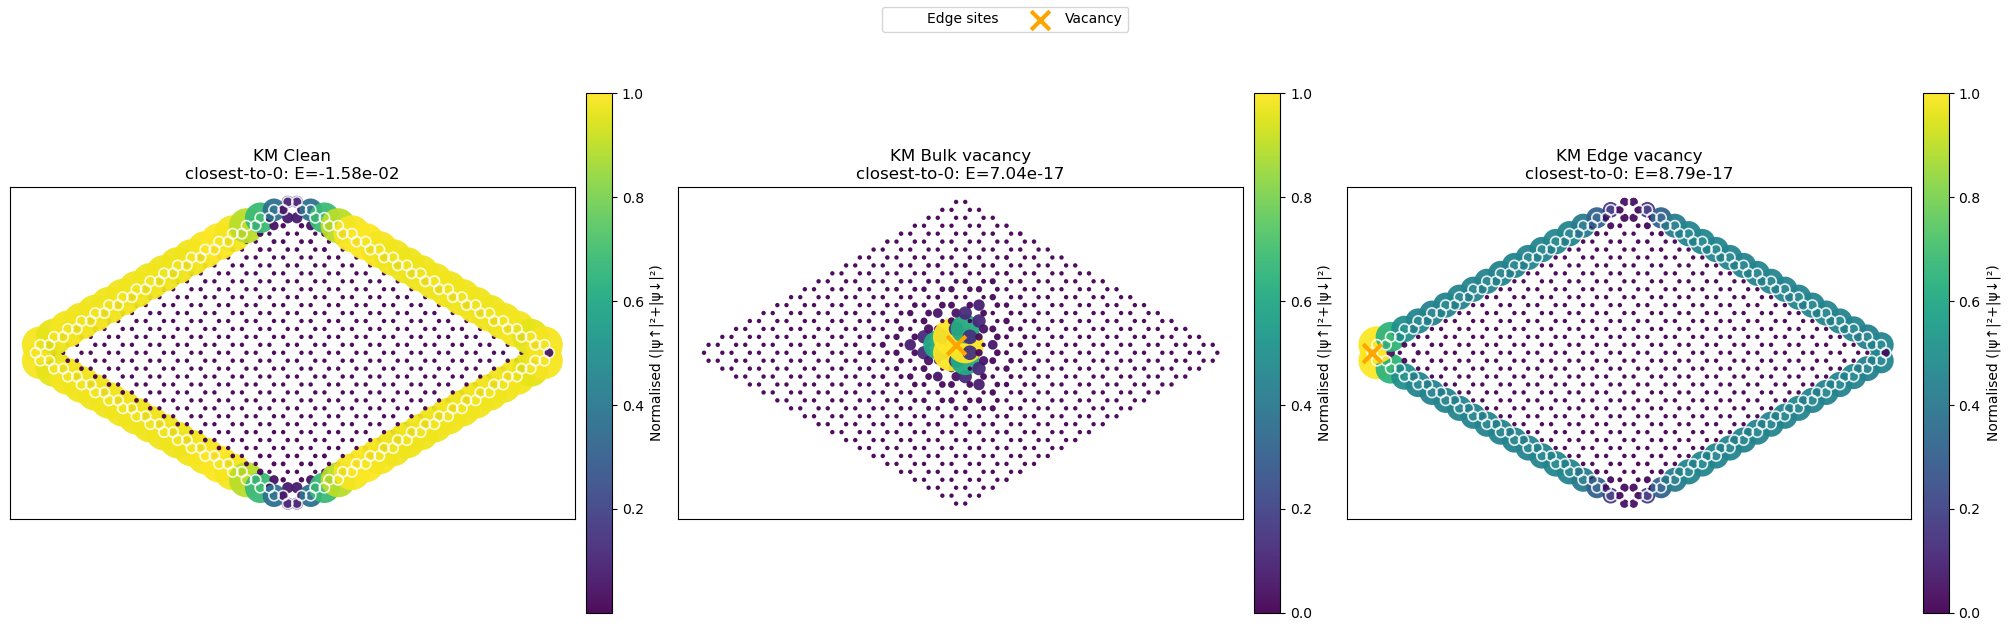

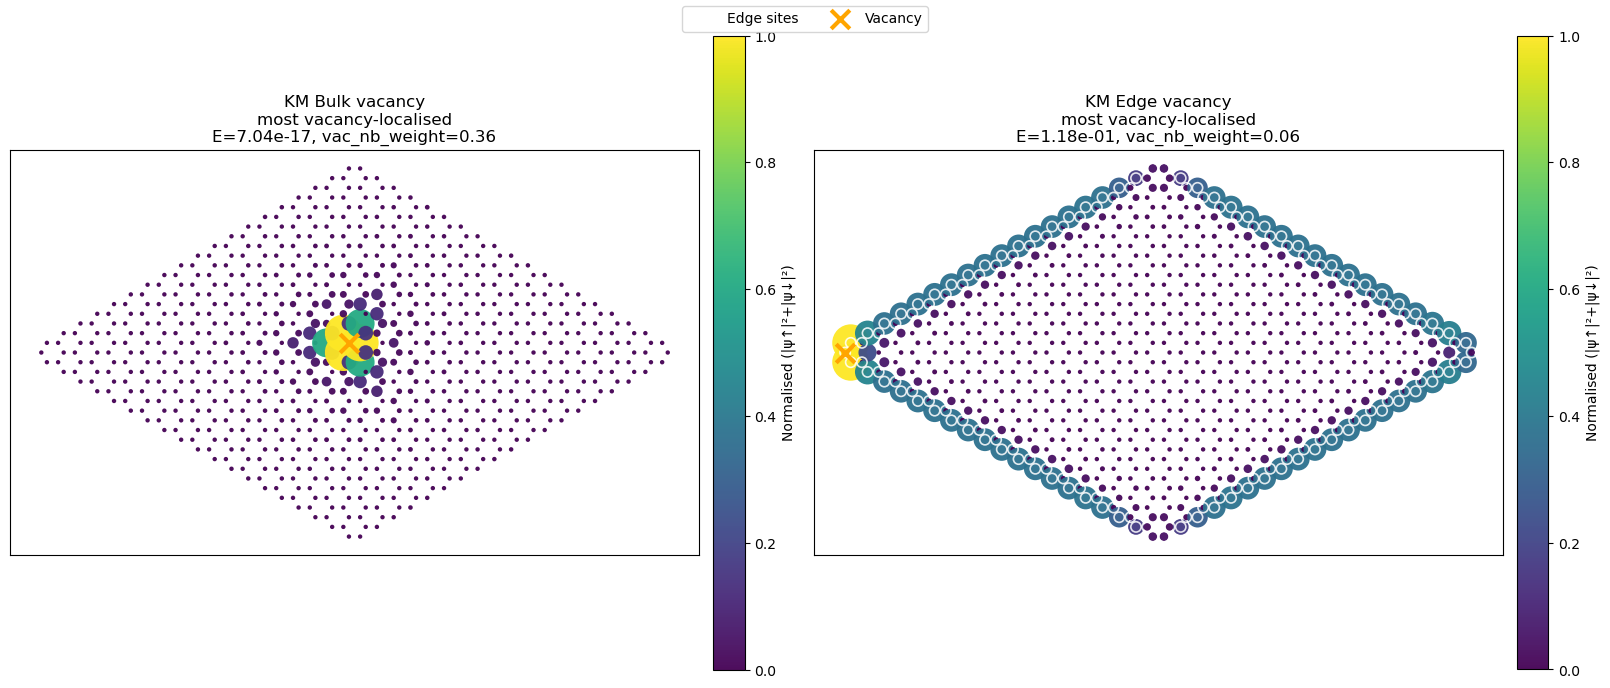

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import topological_insulator
from topological_insulator import Problem
print("Imported from:", topological_insulator.__file__)
importlib.reload(topological_insulator)

# Paths and problem setup (same as before)

structure_path = "/Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/data/structures"

N_r = 20  # island linear size
problem = Problem(structure_path=structure_path, structure_name="honeycomb.json")

problem.setup(
    N_r=N_r,
    N_k=1,                 # island doesn't use BZ
    location="island",
    BZ="reduced",
    dangling_bonds=False
)

problem.run(H_type="real")  # we mainly want geometry built by the library

geom = problem.geometry
sites = np.asarray(geom.sites, dtype=float)
N_full = len(sites)

print("Clean island:")
print("  sites:", N_full)

edge_set = set(getattr(geom, "edge_indices", []))
print("  edge sites:", len(edge_set))


# Example if your file is: islandkm_tb.py
from topological_insulator.python.hamiltonian.tight_binding.islandkm_tb import TightBindingKMIsland

# Build + solve KM clean island

tb = TightBindingKMIsland(problem.model_options, problem.cell_parser)

tb.t = -1.0
tb.lam_so = 0.06
tb.mass = 0.0

tb.build_hamiltonian(geom)
tb.solve_eigenvalues(geom, H_type="real")

H_clean = np.asarray(tb.H)
E0 = np.asarray(tb.E)
U0 = np.asarray(tb.U)  # columns are eigenvectors in spinful basis (length 2N)

print("\nKM clean island:")
print("  dim:", H_clean.shape[0], "(= 2N)")
print("  eigenvalues:", len(E0))
print("  E min/max:", float(E0.min()), float(E0.max()))
print("  t used:", getattr(tb, "t", None), "lam_so:", getattr(tb, "lam_so", None), "mass:", getattr(tb, "mass", None))

# Vacancy candidates (same logic)

def pick_site_near_point(xy, exclude_edge=False):
    d = np.sum((sites - np.array(xy))**2, axis=1)
    order = np.argsort(d)
    for idx in order:
        if exclude_edge and idx in edge_set:
            continue
        return int(idx)
    return int(order[0])

centre = np.mean(sites, axis=0)
vac_bulk = pick_site_near_point(centre, exclude_edge=True)

if len(edge_set) > 0:
    vac_edge = int(sorted(list(edge_set))[0])
else:
    vac_edge = int(np.argmin(sites[:, 0]))

print("\nVacancy candidates:")
print("  bulk-like vacancy idx:", vac_bulk, "coord:", sites[vac_bulk])
print("  edge vacancy idx:", vac_edge, "coord:", sites[vac_edge])

# ------------------------------------------------------------
# 4) Helpers: remove site(s) in spinful basis + diagonalise
# ------------------------------------------------------------
def remove_sites_spin(H, remove_sites):
    """Remove site indices from a spinful Hamiltonian (removes up+down DOFs)."""
    remove_sites = np.atleast_1d(remove_sites).astype(int)
    remove_dofs = []
    for s in remove_sites:
        remove_dofs.extend([2*s, 2*s + 1])

    remove_dofs = np.array(remove_dofs, dtype=int)
    dim = H.shape[0]
    mask = np.ones(dim, dtype=bool)
    mask[remove_dofs] = False
    kept = np.nonzero(mask)[0]
    Hr = H[np.ix_(kept, kept)]
    return Hr, kept

def diag(H):
    return np.linalg.eigh(H)

def closest_to_zero(E):
    i = int(np.argmin(np.abs(E)))
    return i, float(E[i])

# Build vacancy Hamiltonians directly from KM clean H
H_bulk_vac, kept_bulk = remove_sites_spin(H_clean, vac_bulk)
Eb, Ub = diag(H_bulk_vac)

H_edge_vac, kept_edge = remove_sites_spin(H_clean, vac_edge)
Ee, Ue = diag(H_edge_vac)

print("\nKM with 1 vacancy:")
print("  bulk-vac eigenvalues:", len(Eb), "E min/max:", float(Eb.min()), float(Eb.max()))
print("  edge-vac eigenvalues:", len(Ee), "E min/max:", float(Ee.min()), float(Ee.max()))
print("  check: removed one site -> dim drops by 2:", len(E0), "->", len(Eb))

# Near-zero state selection (energy-based)

i0, E0z = closest_to_zero(E0)
ib, Ebz = closest_to_zero(Eb)
ie, Eez = closest_to_zero(Ee)

print("\nNear-zero check (closest eigenvalue to 0):")
print("  clean   : E =", E0z)
print("  bulk-vac: E =", Ebz)
print("  edge-vac: E =", Eez)

# Probabilities per site (sum over spin)

def prob_density_sites_clean(U, mode_index, N_sites):
    """Return p_site (length N_sites) from spinful eigenvectors U (2N x 2N)."""
    psi = U[:, mode_index]  # length 2N
    p_site = np.abs(psi[0::2])**2 + np.abs(psi[1::2])**2
    s = p_site.sum()
    if s > 0:
        p_site /= s
    return p_site

def prob_density_sites_from_reduced(U_reduced, kept_dofs, mode_index, N_sites):
    """Map reduced eigenvector back to full 2N basis, then sum spin per site."""
    psi_red = U_reduced[:, mode_index]
    psi_full = np.zeros(2*N_sites, dtype=complex)
    psi_full[kept_dofs] = psi_red
    p_site = np.abs(psi_full[0::2])**2 + np.abs(psi_full[1::2])**2
    s = p_site.sum()
    if s > 0:
        p_site /= s
    return p_site

p0 = prob_density_sites_clean(U0, i0, N_full)
pb = prob_density_sites_from_reduced(Ub, kept_bulk, ib, N_full)
pe = prob_density_sites_from_reduced(Ue, kept_edge, ie, N_full)

# Vacancy-localised state selection (max neighbour weight)

C = geom.nn_connectivity_matrix.astype(int)

def neighbours(idx):
    return np.where(C[idx] == 1)[0]

def vac_neighbour_weight(p_site, vac_idx):
    nb = neighbours(vac_idx)
    return float(np.sum(p_site[nb]))

def argmax_vac_neighbour_weight(U_reduced, kept_dofs, vac_idx, N_sites):
    nb = neighbours(vac_idx)
    best_j, best_w = None, -1.0
    for j in range(U_reduced.shape[1]):
        p_full = prob_density_sites_from_reduced(U_reduced, kept_dofs, j, N_sites)
        w = float(np.sum(p_full[nb]))
        if w > best_w:
            best_w, best_j = w, j
    return int(best_j), float(best_w)

jb_loc, w_bulk_loc = argmax_vac_neighbour_weight(Ub, kept_bulk, vac_bulk, N_full)
je_loc, w_edge_loc = argmax_vac_neighbour_weight(Ue, kept_edge, vac_edge, N_full)

pb_loc = prob_density_sites_from_reduced(Ub, kept_bulk, jb_loc, N_full)
pe_loc = prob_density_sites_from_reduced(Ue, kept_edge, je_loc, N_full)

print("\nVacancy-localised state selection (max neighbour weight):")
print(f"  Bulk vacancy: state index = {jb_loc}, E = {float(Eb[jb_loc]):.3e}, vac_nb_weight = {w_bulk_loc:.3f}")
print(f"  Edge vacancy: state index = {je_loc}, E = {float(Ee[je_loc]):.3e}, vac_nb_weight = {w_edge_loc:.3f}")

# Localisation metrics

def ipr(p_site):
    return float(np.sum(p_site**2))

def edge_weight(p_site):
    if len(edge_set) == 0:
        return float("nan")
    return float(np.sum(p_site[list(edge_set)]))

print("\nLocalisation metrics (near-zero selection):")
print("  Clean: IPR =", ipr(p0), "edge_weight =", edge_weight(p0))
print("  Bulk vacancy: IPR =", ipr(pb), "edge_weight =", edge_weight(pb), "vac_nb_weight =", vac_neighbour_weight(pb, vac_bulk))
print("  Edge vacancy: IPR =", ipr(pe), "edge_weight =", edge_weight(pe), "vac_nb_weight =", vac_neighbour_weight(pe, vac_edge))

print("\nLocalisation metrics (vacancy-localised selection):")
print("  Bulk vacancy: IPR =", ipr(pb_loc), "edge_weight =", edge_weight(pb_loc), "vac_nb_weight =", vac_neighbour_weight(pb_loc, vac_bulk))
print("  Edge vacancy: IPR =", ipr(pe_loc), "edge_weight =", edge_weight(pe_loc), "vac_nb_weight =", vac_neighbour_weight(pe_loc, vac_edge))

# Plotting

def scatter_prob(ax, p_site, title, vac_idx=None, edge_idx_set=None, cmap="viridis"):
    p_norm = p_site / (p_site.max() + 1e-30)

    sc = ax.scatter(
        sites[:, 0], sites[:, 1],
        s=10 + 700 * p_norm,
        c=p_norm,
        cmap=cmap,
        alpha=0.95,
        linewidths=0
    )

    if edge_idx_set is not None and len(edge_idx_set) > 0:
        edge_idx_list = list(edge_idx_set)
        ax.scatter(
            sites[edge_idx_list, 0], sites[edge_idx_list, 1],
            s=55,
            facecolors="none",
            edgecolors="white",
            linewidths=1.2,
            alpha=0.85,
            label="Edge sites"
        )

    if vac_idx is not None:
        ax.scatter(
            [sites[vac_idx, 0]], [sites[vac_idx, 1]],
            s=180, marker="x", linewidths=3,
            color="orange",
            label="Vacancy"
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

# Figure A: closest-to-zero (energy-based)
fig, axs = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

sc0 = scatter_prob(axs[0], p0, f"KM Clean\nclosest-to-0: E={E0z:.2e}", edge_idx_set=edge_set)
sc1 = scatter_prob(axs[1], pb, f"KM Bulk vacancy\nclosest-to-0: E={Ebz:.2e}", vac_idx=vac_bulk, edge_idx_set=edge_set)
sc2 = scatter_prob(axs[2], pe, f"KM Edge vacancy\nclosest-to-0: E={Eez:.2e}", vac_idx=vac_edge, edge_idx_set=edge_set)

plt.colorbar(sc0, ax=axs[0], fraction=0.046, pad=0.02, label="Normalised (|ψ↑|²+|ψ↓|²)")
plt.colorbar(sc1, ax=axs[1], fraction=0.046, pad=0.02, label="Normalised (|ψ↑|²+|ψ↓|²)")
plt.colorbar(sc2, ax=axs[2], fraction=0.046, pad=0.02, label="Normalised (|ψ↑|²+|ψ↓|²)")

handles, labels = axs[1].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

plt.show()

# Figure B: most vacancy-localised (meeting-note plot)
fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

scb = scatter_prob(
    axs[0], pb_loc,
    f"KM Bulk vacancy\nmost vacancy-localised\nE={float(Eb[jb_loc]):.2e}, vac_nb_weight={w_bulk_loc:.2f}",
    vac_idx=vac_bulk, edge_idx_set=edge_set
)
sce = scatter_prob(
    axs[1], pe_loc,
    f"KM Edge vacancy\nmost vacancy-localised\nE={float(Ee[je_loc]):.2e}, vac_nb_weight={w_edge_loc:.2f}",
    vac_idx=vac_edge, edge_idx_set=edge_set
)

plt.colorbar(scb, ax=axs[0], fraction=0.046, pad=0.02, label="Normalised (|ψ↑|²+|ψ↓|²)")
plt.colorbar(sce, ax=axs[1], fraction=0.046, pad=0.02, label="Normalised (|ψ↑|²+|ψ↓|²)")

handles, labels = axs[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

plt.show()